# Group_11 - Classification BTXRD 2 lớp bằng ResNet-18

## Thông tin nhóm
- Nguyễn Trọng Hiếu – 25C11042 (Nhóm trưởng)
- Trương Lê Bảo Trân – 25C11071

## Đề tài
- Bài toán: Classification - phân lớp ảnh X-quang BTXRD 2 lớp.
- Dataset: BTXRD/classification_2class.
- Nhãn: normal, tumor.
- Mô hình: ResNet-18 pretrained ImageNet.
- Baseline bắt buộc: resize 224x224.

## Kết quả baseline đã chạy
- Accuracy: 0.7046.
- Macro Precision/Recall/F1: 0.7467 / 0.7054 / 0.6920.
- Weighted Precision/Recall/F1: 0.7470 / 0.7046 / 0.6917.
- Confusion matrix: [[141, 141], [25, 255]] theo thứ tự lớp [normal, tumor].


## 1. Import thư viện và thiết lập seed

In [ ]:
from pathlib import Path
from PIL import Image, ImageFile, ImageEnhance
from tqdm import tqdm

import cv2
import os, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Cho phép PIL đọc các ảnh JPEG bị truncated nhẹ.
# Một số ảnh X-quang trong dataset có thể thiếu vài byte cuối nhưng vẫn hiển thị được.
ImageFile.LOAD_TRUNCATED_IMAGES = True


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
import torchvision.transforms.functional as TF
from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


## 2. Mount Drive / chuẩn bị môi trường Colab

In [ ]:
# Mount Google Drive for exporting result
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Không chạy trong Colab hoặc chưa cần mount Drive:", e)

Không chạy trong Colab hoặc chưa cần mount Drive: mount failed


In [ ]:
!pip install --upgrade -q gdown

## 3. Tải và giải nén dataset

In [ ]:
# # Share online downloading (too low!)
# !gdown -q --folder https://drive.google.com/drive/folders/1NDQJM5IdigYOSBctLQ-Yp7gPJ87HVMg2?usp=drive_link

# # zip download (more faster)
# !gdown https://drive.google.com/uc?id=14YqfM7vnArKhEMNVuFIXWoRGs3gHa82c # 3 class
!gdown https://drive.google.com/uc?id=1qDWk67xB2JSli4liueEgNSqZz9Rs6xWN # 2 class

In [ ]:
!unzip -n -q TGMT_RTXRD_classification_2class.zip

## 4. Cấu hình dataset và tham số huấn luyện

In [ ]:
# ============================================================
# CẤU HÌNH DATASET
# ============================================================

GROUP_ID = "Group_11"
STUDENT_1 = "Nguyễn Trọng Hiếu – 25C11042"
STUDENT_2 = "Trương Lê Bảo Trân – 25C11071"

PROJECT_FOLDER_NAME = "TH_TGMT_DTTLoan_Segmentation_Classification_YKhoa"

# Chọn dataset:
#   "BTXRD" hoặc "FracAtlas"
DATASET_NAME = "BTXRD"

BTXRD_CLASS_TASK = "classification_2class"
LABEL_COLUMN = "label_binary"

# resize là phần bắt buộc; keep_ratio_padding/no_resize là option nâng cao
PREPROCESS_MODE = "resize"       # "resize" | "keep_ratio_padding" | "no_resize"
TARGET_SIZE = 224
# BATCH_SIZE = 16 if PREPROCESS_MODE != "no_resize" else 1
BATCH_SIZE = 256 if PREPROCESS_MODE != "no_resize" else 1

# Với FracAtlas mất cân bằng lớp, nên dùng pretrained + sampler.
EPOCHS = 5
LR = 1e-4
USE_PRETRAINED = True
# USE_WEIGHTED_SAMPLER = True
USE_WEIGHTED_SAMPLER = False
USE_CLASS_WEIGHTED_LOSS = False   # Nếu đã dùng sampler, thường để False để tránh quá bù lớp thiểu số.
FREEZE_BACKBONE = False

# Để demo seminar chạy nhanh:
# - Nếu muốn train nhanh nhưng vẫn không lệch lớp: đặt MAX_TRAIN_SAMPLES = 1200.
# - Nếu muốn kết quả chính thức hơn: đặt MAX_TRAIN_SAMPLES = None.
# - Không nên lấy 500 dòng đầu vì có thể làm lệch phân bố.
MAX_TRAIN_SAMPLES = 1200
MAX_TEST_SAMPLES = None

OUTPUT_DIR = Path("/content/classification_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def find_project_root(project_name=PROJECT_FOLDER_NAME):
    return Path("/content/drive/MyDrive")

PROJECT_ROOT = find_project_root()

DATA_ROOT = Path(BTXRD_CLASS_TASK)

TRAIN_CSV = DATA_ROOT / "train.csv"
VAL_CSV = DATA_ROOT / "val.csv"
TEST_CSV = DATA_ROOT / "test.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("LABEL_COLUMN:", LABEL_COLUMN)
print("PREPROCESS_MODE:", PREPROCESS_MODE)
print("train.csv:", TRAIN_CSV.exists())
print("val.csv:", VAL_CSV.exists())
print("test.csv:", TEST_CSV.exists())

assert DATA_ROOT.exists(), f"Không thấy DATA_ROOT: {DATA_ROOT}"
assert TRAIN_CSV.exists(), f"Không thấy train.csv: {TRAIN_CSV}"
assert TEST_CSV.exists(), f"Không thấy test.csv: {TEST_CSV}"


PROJECT_ROOT: /content/drive/MyDrive
DATA_ROOT: classification_2class
LABEL_COLUMN: label_binary
PREPROCESS_MODE: resize
train.csv: True
val.csv: True
test.csv: True


## 5. Kiểm tra split, phân bố nhãn và ảnh

In [ ]:
# ============================================================
# KIỂM TRA NHANH CSV VÀ ẢNH
# ============================================================

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))
print("\nPhân bố nhãn train:")
print(train_df[LABEL_COLUMN].value_counts())

print("\nPhân bố nhãn test:")
print(test_df[LABEL_COLUMN].value_counts())

required_cols = ["image_id", "image_path", "label_binary", "label_3class", "original_width", "original_height", "split"]
missing_cols = [c for c in required_cols if c not in train_df.columns]
print("\nCột thiếu:", missing_cols)

missing_images = 0
for _, row in test_df.head(200).iterrows():
    if not (DATA_ROOT / row["image_path"]).exists():
        missing_images += 1

print("Số ảnh thiếu trong 200 dòng test đầu:", missing_images)

Train/Val/Test: 2622 562 562

Phân bố nhãn train:
label_binary
normal    1315
tumor     1307
Name: count, dtype: int64

Phân bố nhãn test:
label_binary
normal    282
tumor     280
Name: count, dtype: int64

Cột thiếu: []
Số ảnh thiếu trong 200 dòng test đầu: 0


Nhận xét dựa trên kết quả khảo sát của dataset

- Xét trong tập train:
    - Dữ liệu phôi bố tương đối đều

- Xét trong tập test:
    - Dữ liệu phôn bố tương đối đều

## 6. Tiền xử lý ảnh

In [ ]:
def keep_ratio_resize_pad(img, target=224):
    w, h = img.size
    scale = target / max(w, h)
    nw, nh = int(round(w * scale)), int(round(h * scale))
    img = img.resize((nw, nh), Image.BILINEAR)

    out = Image.new(img.mode, (target, target), 0)
    out.paste(img, ((target - nw) // 2, (target - nh) // 2))
    return out

def preprocess_image(img, mode="resize"):
    ow, oh = img.size

    if mode == "resize":
        img2 = img.resize((TARGET_SIZE, TARGET_SIZE), Image.BILINEAR)
    elif mode == "keep_ratio_padding":
        img2 = keep_ratio_resize_pad(img, TARGET_SIZE)
    elif mode == "no_resize":
        # ResNet dùng adaptive pooling nên có thể nhận kích thước linh hoạt.
        # Tuy nhiên batch_size nên để 1 nếu không resize.
        img2 = img
    else:
        raise ValueError(mode)

    iw, ih = img2.size

    x = TF.to_tensor(img2.convert("RGB"))
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    x = (x - mean) / std

    meta = {
        "original_width": ow,
        "original_height": oh,
        "input_width": iw,
        "input_height": ih,
        "preprocess_mode": mode,
        "is_bonus_option": "yes" if mode != "resize" else "no",
    }
    return x, meta

def preprocess_image_custom(img, mode="resize", apply_action=False, apply_sobel=False):
    ow, oh = img.size

    # =========================================================
    # 1. APPLY MASK AND EXTRACT BONE
    # =========================================================
    if apply_action:
        # Convert to Grayscale and NumPy array
        img_np = np.array(img.convert("L"))

        # 1. APPLY CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_equalized = clahe.apply(img_np)

        # 2. Gentle Blur
        blurred = cv2.GaussianBlur(img_equalized, (5, 5), 0)

        # 3. THRESHOLDING (The Sweet Spot)
        # 0.82 balances perfectly between dropping muscle and keeping bone edges
        strict_otsu_val, _ = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        sweet_spot_val = strict_otsu_val * 0.82
        _, binary_mask = cv2.threshold(blurred, sweet_spot_val, 255, cv2.THRESH_BINARY)

        # 4. SNAP THE BRIDGES
        kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        opened_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel_small, iterations=1)

        # 5. FILTER OUT THE MUSCLE
        contours, _ = cv2.findContours(opened_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        solid_mask = np.zeros_like(img_np)

        if contours:
            min_area = (img_np.shape[0] * img_np.shape[1]) * 0.01
            valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
            cv2.drawContours(solid_mask, valid_contours, -1, 255, thickness=cv2.FILLED)

        # 6. HEAL THE BITES (Stronger Re-inflation)
        # Using a larger 9x9 kernel to act like "putty", filling in the bite marks
        kernel_heal = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        solid_mask = cv2.morphologyEx(solid_mask, cv2.MORPH_CLOSE, kernel_heal, iterations=2)

        # Slightly larger 5x5 safety margin to gently recover the faint transparent edges
        kernel_margin = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        solid_mask = cv2.dilate(solid_mask, kernel_margin, iterations=1)

        # 7. Smooth the final mask edges
        solid_mask = cv2.GaussianBlur(solid_mask, (5, 5), 0)
        _, solid_mask = cv2.threshold(solid_mask, 127, 255, cv2.THRESH_BINARY)

        # 8. Apply the mask
        extracted_bone = cv2.bitwise_and(img_np, img_np, mask=solid_mask)

        # Convert back to PIL Image
        img = Image.fromarray(extracted_bone)

    # =========================================================
    # 1. ÁP DỤNG MASK SOBEL TRƯỚC KHI RESIZE / PADDING
    # =========================================================
    elif apply_sobel:
        # Ép về Grayscale và chuyển sang NumPy array
        img_np = np.array(img.convert("L"))

        # Làm mờ để giảm nhiễu hạt
        blurred_xray = cv2.GaussianBlur(img_np, (3, 3), 0)

        # Xử lý Sobel (Tính cả X và Y)
        sobel_x = cv2.Sobel(blurred_xray, cv2.CV_64F, dx=1, dy=0, ksize=3)
        sobel_y = cv2.Sobel(blurred_xray, cv2.CV_64F, dx=0, dy=1, ksize=3)

        # Đưa về chuẩn ảnh 8-bit
        sobel_x = cv2.convertScaleAbs(sobel_x)
        sobel_y = cv2.convertScaleAbs(sobel_y)

        # Kết hợp Sobel X và Sobel Y
        sobel_combined = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

        # Cập nhật lại biến img bằng ảnh đã qua xử lý Sobel
        img = Image.fromarray(sobel_combined)

        # Tăng độ tương phản lên 1.5 cho vùng xương nguyên bản vừa cắt ra
        enhancer = ImageEnhance.Contrast(img)
        img = enhancer.enhance(8)


    # =========================================================
    # 2. XỬ LÝ KÍCH THƯỚC (RESIZE / PADDING)
    # =========================================================
    if mode == "resize":
        # Kiểm tra và thêm Black Padding nếu ảnh không vuông
        if ow != oh:
            max_dim = max(ow, oh)
            # Dùng img.mode để đảm bảo giữ đúng hệ màu hiện tại
            square_img = Image.new(img.mode, (max_dim, max_dim), 0)
            square_img.paste(img, (0, 0))
            img_to_resize = square_img
        else:
            img_to_resize = img

        img2 = img_to_resize.resize((TARGET_SIZE, TARGET_SIZE), Image.BILINEAR)
        img2 = keep_ratio_resize_pad(img, TARGET_SIZE)
    elif mode == "no_resize":
        # ResNet dùng adaptive pooling nên có thể nhận kích thước linh hoạt.
        # Tuy nhiên batch_size nên để 1 nếu không resize.
        img2 = img
    else:
        raise ValueError(mode)

    iw, ih = img2.size

    x = TF.to_tensor(img2.convert("RGB"))
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    x = (x - mean) / std

    meta = {
        "original_width": ow,
        "original_height": oh,
        "input_width": iw,
        "input_height": ih,
        "preprocess_mode": mode,
        "is_bonus_option": "yes" if mode != "resize" else "no",
    }
    return x, meta



In [ ]:
def is_readable_image(path):
    """
    Kiểm tra ảnh có đọc được không.
    ImageFile.LOAD_TRUNCATED_IMAGES=True đã được bật ở cell import,
    nên các ảnh JPEG bị truncated nhẹ vẫn có thể đọc.
    """
    try:
        with Image.open(path) as img:
            img.load()
        return True
    except Exception:
        return False


class ClassificationDataset(Dataset):
    def __init__(self, root, csv_path, label_col="label_binary", check_images=True):
        self.root = Path(root)
        self.df = pd.read_csv(csv_path).copy()
        self.label_col = label_col

        # Chỉ giữ ảnh có tồn tại
        self.df = self.df[self.df["image_path"].apply(lambda p: (self.root / p).exists())].reset_index(drop=True)

        # Lọc ảnh hỏng nặng nếu còn lỗi sau khi bật LOAD_TRUNCATED_IMAGES
        if check_images:
            bad_rows = []
            keep_rows = []

            for idx, row in self.df.iterrows():
                img_path = self.root / row["image_path"]
                if is_readable_image(img_path):
                    keep_rows.append(idx)
                else:
                    bad_rows.append((idx, str(row.get("image_id", "")), str(img_path)))

            if len(bad_rows) > 0:
                print(f"Cảnh báo: loại {len(bad_rows)} ảnh không đọc được trong {csv_path}")
                print("Ví dụ ảnh lỗi:")
                for item in bad_rows[:10]:
                    print(" -", item[1], item[2])

            self.df = self.df.loc[keep_rows].reset_index(drop=True)

        if len(self.df) == 0:
            raise RuntimeError("Không có ảnh hợp lệ theo CSV.")

        self.classes = sorted(self.df[label_col].astype(str).unique())
        self.label_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img_path = self.root / row["image_path"]

        try:
            with Image.open(img_path) as img:
                img = img.convert("L")
                # ép PIL load ngay tại đây để tránh lỗi ẩn trong DataLoader worker
                img.load()
        except Exception as e:
            raise OSError(f"Lỗi đọc ảnh: {img_path}. Chi tiết: {e}")

        # x, meta = preprocess_image(img, PREPROCESS_MODE)
        x, meta = preprocess_image_custom(img, PREPROCESS_MODE, apply_action=True)

        label_name = str(row[self.label_col])
        y = self.label_to_idx[label_name]

        meta.update({
            "image_id": str(row["image_id"]),
            "label_name": label_name,
            "split": str(row.get("split", "")),
        })

        return x, y, meta


def make_stratified_subset_indices(ds, max_samples, seed=42):
    """
    Nếu muốn giới hạn số mẫu để demo nhanh, không lấy các dòng đầu tiên.
    Hàm này lấy mẫu theo từng lớp để tránh subset bị lệch lớp.
    """
    if max_samples is None or max_samples >= len(ds):
        return None

    rng = np.random.default_rng(seed)
    label_values = ds.df[ds.label_col].astype(str).values

    classes_local = sorted(np.unique(label_values))
    n_classes = len(classes_local)
    base_per_class = max_samples // n_classes
    remainder = max_samples % n_classes

    selected = []

    for k, cls_name in enumerate(classes_local):
        idx = np.where(label_values == cls_name)[0]
        rng.shuffle(idx)

        take = min(len(idx), base_per_class + (1 if k < remainder else 0))
        selected.extend(idx[:take].tolist())

    rng.shuffle(selected)
    return selected


def get_targets_from_dataset(ds):
    """
    Trả về target index cho Dataset hoặc Subset.
    """
    if isinstance(ds, Subset):
        base = ds.dataset
        targets = []
        for idx in ds.indices:
            label_name = str(base.df.iloc[idx][base.label_col])
            targets.append(base.label_to_idx[label_name])
        return np.array(targets, dtype=np.int64)

    targets = []
    for _, row in ds.df.iterrows():
        label_name = str(row[ds.label_col])
        targets.append(ds.label_to_idx[label_name])
    return np.array(targets, dtype=np.int64)


## 7. Tạo Dataset, DataLoader và kiểm tra lớp

In [ ]:

train_base = ClassificationDataset(DATA_ROOT, TRAIN_CSV, LABEL_COLUMN, check_images=True)
val_ds = ClassificationDataset(DATA_ROOT, VAL_CSV, LABEL_COLUMN, check_images=True)
test_base = ClassificationDataset(DATA_ROOT, TEST_CSV, LABEL_COLUMN, check_images=True)

# # Lấy subset train theo kiểu stratified/balanced, không lấy n dòng đầu.
# train_indices = make_stratified_subset_indices(train_base, MAX_TRAIN_SAMPLES, SEED)
# if train_indices is not None:
#     train_ds = Subset(train_base, train_indices)
# else:
#     train_ds = train_base

# # Test có thể giới hạn để chạy nhanh, nhưng nên giữ stratified.
# test_indices = make_stratified_subset_indices(test_base, MAX_TEST_SAMPLES, SEED)
# if test_indices is not None:
#     test_ds = Subset(test_base, test_indices)
# else:
#     test_ds = test_base

train_ds = train_base
test_ds = test_base

# Nếu dùng Subset, lấy classes từ dataset gốc
classes = train_ds.dataset.classes if isinstance(train_ds, Subset) else train_ds.classes

train_targets = get_targets_from_dataset(train_ds)
class_counts = np.bincount(train_targets, minlength=len(classes))

print("Classes:", classes)
print("Batch size:", BATCH_SIZE)
print("Train/Test dùng trong notebook:", len(train_ds), len(test_ds))
print("Phân bố train thật sự trong notebook:")
for i, c in enumerate(classes):
    print(f"  {c}: {int(class_counts[i])}")

if USE_WEIGHTED_SAMPLER:
    # WeightedRandomSampler giúp mỗi batch nhìn thấy lớp thiểu số nhiều hơn,
    # nhưng không thay đổi split/test gốc.
    sample_weights = 1.0 / np.maximum(class_counts[train_targets], 1)
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

if USE_CLASS_WEIGHTED_LOSS:
    class_weights = len(train_targets) / (len(classes) * np.maximum(class_counts, 1))
    CLASS_WEIGHTS_TENSOR = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    print("Class weights dùng cho loss:", dict(zip(classes, class_weights)))
else:
    CLASS_WEIGHTS_TENSOR = None

Classes: ['normal', 'tumor']
Batch size: 256
Train/Test dùng trong notebook: 2622 562
Phân bố train thật sự trong notebook:
  normal: 1315
  tumor: 1307


In [ ]:
def show_before_after_images(dataset, num_samples=5, normal: bool = True):
    # 1. Tìm các index thỏa mãn điều kiện (Normal hoặc Tumor)
    target_indices = []

    # Giả định nhãn của bạn có chứa chữ "normal" hoặc "tumor" (chữ hoa hay thường đều được)
    # Lưu ý: Nếu label trong CSV của bạn là số (VD: 0 và 1), bạn hãy sửa lại đoạn này.
    target_keyword = "normal" if normal else "tumor"

    for i in range(len(dataset)):
        # Trích xuất trực tiếp từ DataFrame để tìm label nhanh chóng mà không cần load ảnh
        if isinstance(dataset, Subset):
            base_ds = dataset.dataset
            real_idx = dataset.indices[i]
        else:
            base_ds = dataset
            real_idx = i

        # Lấy tên label hiện tại và chuyển về chữ thường
        label_name = str(base_ds.df.iloc[real_idx][base_ds.label_col]).lower()

        # Nếu nhãn khớp với keyword ta đang tìm
        if target_keyword in label_name:
            target_indices.append(i)

        # Dừng lại ngay khi đã thu thập đủ số lượng
        if len(target_indices) == num_samples:
            break

    # Kiểm tra an toàn lỡ như không tìm đủ ảnh
    if len(target_indices) < num_samples:
        print(f"Cảnh báo: Chỉ tìm thấy {len(target_indices)} ảnh thuộc lớp chứa từ khóa '{target_keyword}'.")
        if len(target_indices) == 0:
            return
        num_samples = len(target_indices)

    # 2. Tạo khung hình
    fig, axes = plt.subplots(2, num_samples, figsize=(3 * num_samples, 6))

    # Xử lý ngoại lệ nếu num_samples = 1 thì axes là mảng 1 chiều, cần ép về 2 chiều
    if num_samples == 1:
        axes = axes.reshape(2, 1)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # 3. Lặp qua các ảnh mục tiêu đã tìm được và hiển thị
    for plot_idx, ds_idx in enumerate(target_indices):
        # Lúc này ta mới thực sự gọi dataset[ds_idx] để load và preprocess ảnh
        x, y, meta = dataset[ds_idx]

        if isinstance(dataset, Subset):
            base_ds = dataset.dataset
            real_idx = dataset.indices[ds_idx]
        else:
            base_ds = dataset
            real_idx = ds_idx

        row = base_ds.df.iloc[real_idx]
        img_path = base_ds.root / row["image_path"]
        orig_img = Image.open(img_path).convert("RGB")

        # Un-normalize ảnh sau xử lý
        img_after = x.permute(1, 2, 0).numpy()
        img_after = img_after * std + mean
        img_after = np.clip(img_after, 0, 1)

        # Vẽ ảnh gốc
        ax_orig = axes[0, plot_idx]
        ax_orig.imshow(orig_img)
        ax_orig.set_title(f"Gốc: {meta['original_width']}x{meta['original_height']}\nLabel: {meta['label_name']}")
        ax_orig.axis("off")

        # Vẽ ảnh sau xử lý
        ax_after = axes[1, plot_idx]
        ax_after.imshow(img_after)
        ax_after.set_title(f"Xử lý: {meta['input_width']}x{meta['input_height']}\nMode: {meta['preprocess_mode']}")
        ax_after.axis("off")

    plt.tight_layout()
    plt.show()

## 8. Minh họa ảnh normal sau tiền xử lý

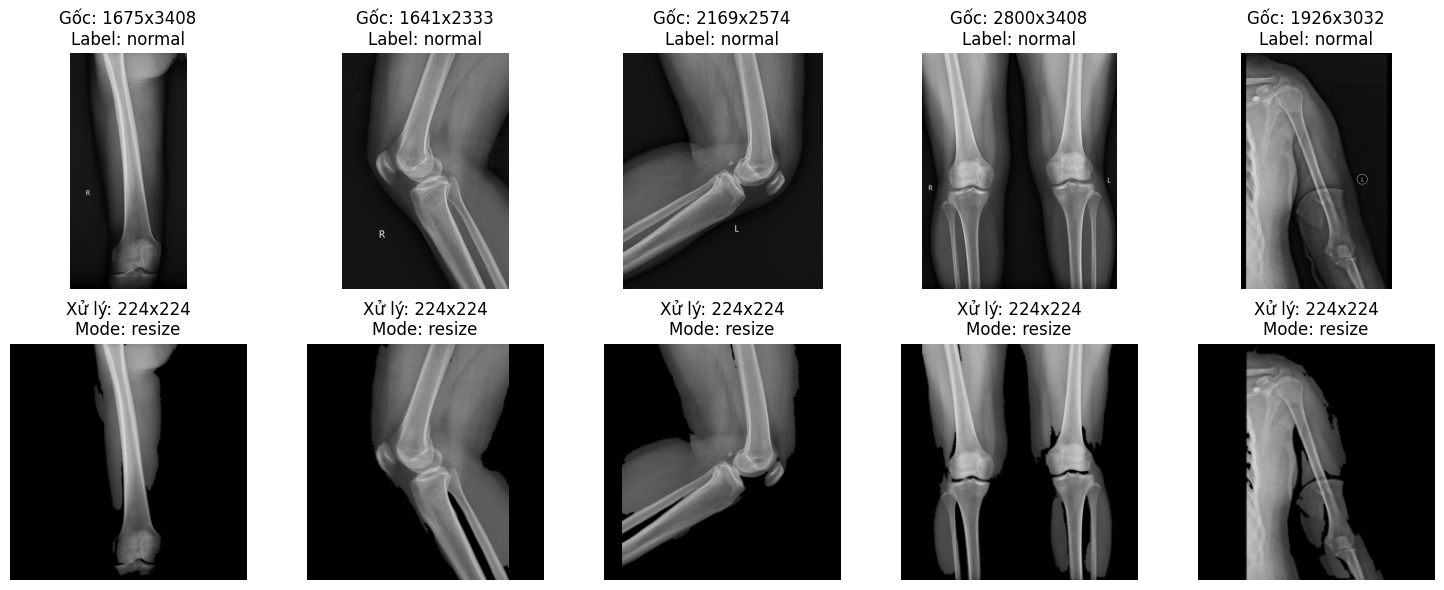

In [ ]:
# Hiển thị 5 ảnh NORMAL
show_before_after_images(train_ds, num_samples=5, normal=True)

## 9. Minh họa ảnh tumor sau tiền xử lý

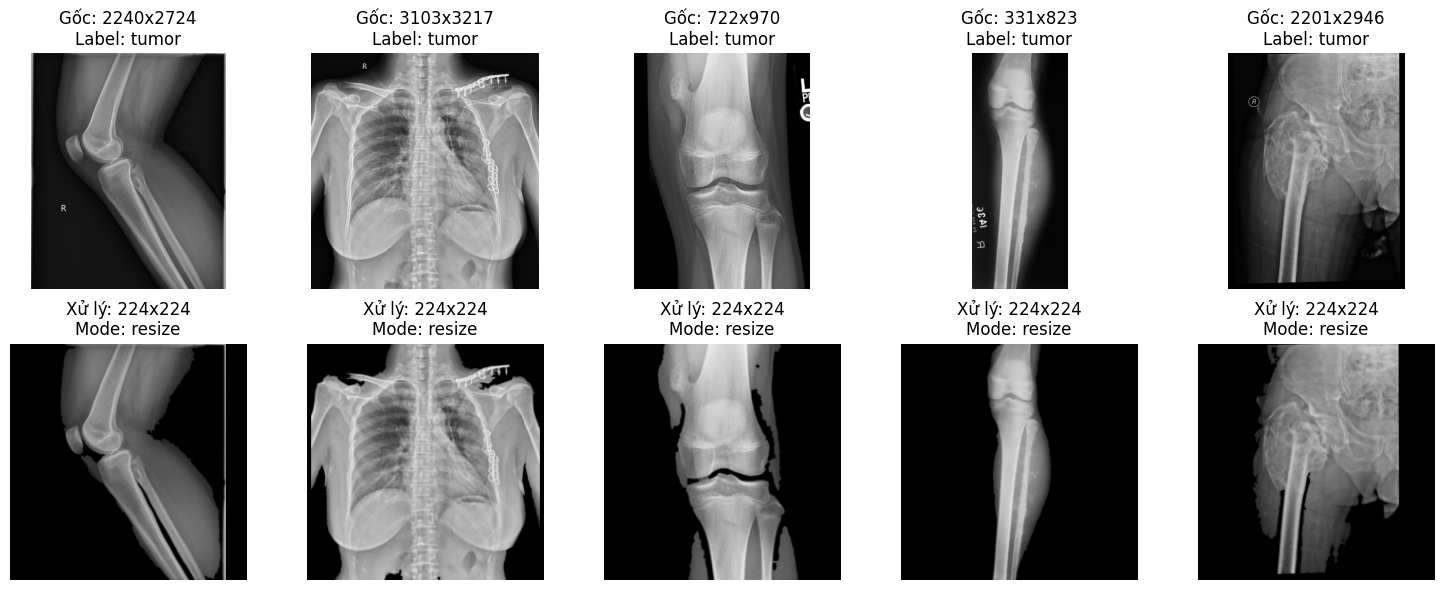

In [ ]:
# Hiển thị 5 ảnh TUMOR
show_before_after_images(train_ds, num_samples=5, normal=False)

## 10. Khởi tạo ResNet-18

In [ ]:
# ============================================================
# MODEL RESNET18
# ============================================================

# Với tập nhỏ/mất cân bằng, dùng pretrained thường ổn định hơn weights=None.
if USE_PRETRAINED:
    try:
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        print("Đang dùng ResNet18 pretrained ImageNet.")
    except Exception as e:
        print("Không tải được pretrained weights, dùng weights=None. Lỗi:", e)
        model = models.resnet18(weights=None)
else:
    model = models.resnet18(weights=None)

if FREEZE_BACKBONE:
    for p in model.parameters():
        p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(classes))

# Nếu freeze backbone thì cần mở lại fc
for p in model.fc.parameters():
    p.requires_grad = True

model = model.to(DEVICE)

loss_fn = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)



# for epoch in range(EPOCHS):
#     model.train()
#     losses = []

#     for x, y, meta in train_loader:
#         x = x.to(DEVICE)
#         y = y.to(DEVICE)

#         optimizer.zero_grad()
#         out = model(x)
#         loss = loss_fn(out, y)
#         loss.backward()
#         optimizer.step()

#         losses.append(loss.item())

#     print(f"Epoch {epoch+1}/{EPOCHS} - loss={np.mean(losses):.4f}")


Đang dùng ResNet18 pretrained ImageNet.


## 11. Huấn luyện mô hình

In [ ]:
for epoch in range(EPOCHS):
    model.train()
    losses = []

    # Wrap train_loader with tqdm and give it a description
    p_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for x, y, meta in p_bar:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        # Update the progress bar with the current batch loss
        p_bar.set_postfix(loss=f"{loss.item():.4f}")

    # Print the average loss at the end of the epoch
    print(f"Kết thúc Epoch {epoch+1}/{EPOCHS} - avg_loss={np.mean(losses):.4f}")

Epoch 1/5: 100%|██████████| 11/11 [04:37<00:00, 25.25s/it, loss=0.5442]


Kết thúc Epoch 1/5 - avg_loss=0.6133


Epoch 2/5: 100%|██████████| 11/11 [04:32<00:00, 24.75s/it, loss=0.3406]


Kết thúc Epoch 2/5 - avg_loss=0.3493


Epoch 3/5: 100%|██████████| 11/11 [04:30<00:00, 24.58s/it, loss=0.1271]


Kết thúc Epoch 3/5 - avg_loss=0.1869


Epoch 4/5: 100%|██████████| 11/11 [04:29<00:00, 24.52s/it, loss=0.0532]


Kết thúc Epoch 4/5 - avg_loss=0.0753


Epoch 5/5: 100%|██████████| 11/11 [04:30<00:00, 24.58s/it, loss=0.0160]

Kết thúc Epoch 5/5 - avg_loss=0.0282


## 12. Đánh giá và xuất results CSV

In [ ]:
# ============================================================
# ĐÁNH GIÁ VÀ XUẤT CSV ĐÚNG TEMPLATE
# ============================================================

rows = []
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for x, y, meta in test_loader:
        out = model(x.to(DEVICE))
        prob = torch.softmax(out, dim=1).cpu().numpy()[0]
        pred = int(prob.argmax())
        true = int(y.item())

        y_true.append(true)
        y_pred.append(pred)

        row = {
            "group_id": "Group_11",
            "student_1": "",
            "student_2": "",
            "task_id": "Group_11_classification_2class",
            "dataset": DATASET_NAME,
            "model": "ResNet-18",
            "image_id": meta["image_id"][0],
            "split": "test",
            "original_width": int(meta["original_width"][0]),
            "original_height": int(meta["original_height"][0]),
            "input_width": int(meta["input_width"][0]),
            "input_height": int(meta["input_height"][0]),
            "preprocess_mode": meta["preprocess_mode"][0],
            "is_bonus_option": meta["is_bonus_option"][0],
            "bonus_score": 1.0 if meta["is_bonus_option"][0] == "yes" else 0.0,
            "y_true": classes[true],
            "y_pred": classes[pred],
            "correct": int(true == pred),
            "note": "",
        }

        # Xác suất dự đoán theo lớp
        for i, c in enumerate(classes):
            row[f"prob_{c}"] = float(prob[i])

        rows.append(row)

acc = accuracy_score(y_true, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

# Ghi metric tổng vào từng dòng để đúng template
cm = confusion_matrix(y_true, y_pred)
cm_str = str(cm.tolist())

for r in rows:
    r["accuracy"] = acc
    r["precision"] = precision_macro
    r["recall"] = recall_macro
    r["f1_score"] = f1_macro
    r["confusion_matrix"] = cm_str
    r["precision_macro"] = precision_macro
    r["recall_macro"] = recall_macro
    r["f1_score_macro"] = f1_macro
    r["precision_weighted"] = precision_weighted
    r["recall_weighted"] = recall_weighted
    r["f1_score_weighted"] = f1_weighted
    r["confusion_matrix_image"] = "figures/confusion_matrix_Group11.png"

result_df = pd.DataFrame(rows)

out_csv = OUTPUT_DIR / "results_Group11.csv"
result_df.to_csv(out_csv, index=False, encoding="utf-8-sig")

print("Saved:", out_csv)
display(result_df.head())

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=classes, digits=4, zero_division=0))

unique_pred = sorted(set(y_pred))
if len(unique_pred) == 1:
    print("\nCẢNH BÁO: Mô hình đang dự đoán duy nhất một lớp:", classes[unique_pred[0]])
    print("Hãy tăng EPOCHS, dùng USE_PRETRAINED=True, USE_WEIGHTED_SAMPLER=True, hoặc dùng thêm class-weighted loss.")
else:
    print("\nMô hình đã dự đoán nhiều hơn một lớp:", [classes[i] for i in unique_pred])

Saved: /content/classification_outputs/results_Group11.csv



Classification report:
              precision    recall  f1-score   support

      normal     0.8494    0.5000    0.6295       282
       tumor     0.6439    0.9107    0.7544       280

    accuracy                         0.7046       562
   macro avg     0.7467    0.7054    0.6920       562
weighted avg     0.7470    0.7046    0.6917       562


Mô hình đã dự đoán nhiều hơn một lớp: ['normal', 'tumor']


## 13. Lưu confusion matrix

Saved: /content/classification_outputs/confusion_matrix.png


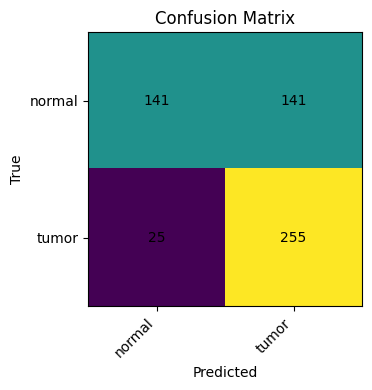

In [ ]:
## ============================================================
# LƯU CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

fig_path = OUTPUT_DIR / "figures/confusion_matrix_Group11.png"
plt.savefig(fig_path, dpi=150)
print("Saved:", fig_path)

## 14. Nhận xét nhanh từ kết quả chạy

Mô hình ResNet-18 trên BTXRD/classification_2class đạt accuracy 0.7046 trên tập test 562 ảnh. Recall của lớp tumor đạt 0.9107, cho thấy mô hình phát hiện được phần lớn ảnh tumor. Tuy nhiên recall của lớp normal chỉ đạt 0.5000, nghĩa là còn nhiều ảnh normal bị dự đoán nhầm thành tumor. Confusion matrix `[[141, 141], [25, 255]]` cho thấy lỗi chính là false positive ở lớp tumor.

Option `keep_ratio_padding/no_resize` đã có code chuẩn bị trong notebook, nhưng chưa có output metric riêng trong lần chạy hiện tại nên báo cáo không tính điểm cộng option.
